# Entrega 003 — Algoritmos Não Supervisionados

**FACOM32701 – Ciência de Dados II | UFU**  
**Tema 14 – Fake News e Informação Online**  
**Dataset:** FactCenter — 11.539 registros de fact-checking brasileiros

---

## Objetivo

Aplicar e comparar algoritmos de agrupamento (**K-Means**, **Hierárquico** e **DBSCAN**) sobre os embeddings do dataset FactCenter, avaliando coesão, separação e pureza dos clusters em relação às classes reais (`rating_norm`) e às agências (`source_name`).

## Pipeline

```
embeddings (1024-d)  →  X_pca (424-d, 95% variância)  →  StandardScaler  →  Clustering
                                                        →  umap_2d (2-d)   →  Visualização
```

**Artefatos carregados de** `../../artifacts/`

---
## 1. Imports e Carregamento dos Artefatos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from itertools import combinations

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
SEED = 42

# ── Caminhos ─────────────────────────────────────────────────────────────────
ARTIFACTS = Path('../../artifacts')

X_pca   = np.load(ARTIFACTS / 'X_pca.npy')      # (11539, 424)
X_umap  = np.load(ARTIFACTS / 'umap_2d.npy')    # (11539, 2)
df      = pd.read_parquet(ARTIFACTS / 'df_clean.parquet')

print(f'X_pca  : {X_pca.shape}')
print(f'X_umap : {X_umap.shape}')
print(f'df     : {df.shape}')
print(f'\nDistribuição de rating_norm:\n{df["rating_norm"].value_counts()}')
print(f'\nDistribuição de source_name:\n{df["source_name"].value_counts()}')

X_pca  : (11539, 424)
X_umap : (11539, 2)
df     : (11539, 9)

Distribuição de rating_norm:
rating_norm
falso           10142
enganoso         1129
verdadeiro        204
inconclusivo       64
Name: count, dtype: int64

Distribuição de source_name:
source_name
boatos              5519
lupa                2549
aos fatos           1600
fato-ou-fake         917
estadao_verifica     593
comprova             361
Name: count, dtype: int64


Quase metade do dataset (47,8%) vem de uma única agência (boatos) que classifica 100% dos seus registros como falso. Isso cria uma estrutura de dados fortemente enviesada para os algoritmos de clustering — qualquer cluster que isole a agência "boatos" terá pureza altíssima em falso, mas isso não representa aprendizado semântico real, apenas separação por fonte.

---
## 2. Pré-processamento: Normalização

O K-Means é sensível à escala (distância euclidiana). Aplicamos **StandardScaler** sobre o `X_pca` antes dos algoritmos particionais. Para o DBSCAN com distância cosseno, utilizamos vetores L2-normalizados (equivalente à cosseno no espaço normalizado).

> **Por quê StandardScaler e não MinMaxScaler?**  
> Embeddings PCA já têm variância decrescente por construção. O StandardScaler padroniza por desvio-padrão, preservando a estrutura relativa das componentes sem compressão extrema dos outliers — mais adequado para espaços de alta dimensão como o nosso (424-d).

In [2]:
# Padronização para K-Means / Hierárquico (distância Euclidiana)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# L2-normalização para DBSCAN com cosseno
norms = np.linalg.norm(X_pca, axis=1, keepdims=True)
X_l2 = X_pca / np.where(norms == 0, 1, norms)

# Rótulos reais codificados numericamente
le_rating = LabelEncoder()
le_source = LabelEncoder()
y_rating = le_rating.fit_transform(df['rating_norm'])
y_source = le_source.fit_transform(df['source_name'])

LABEL_COLORS_RATING = {
    'falso':        '#e74c3c',
    'enganoso':     '#e67e22',
    'verdadeiro':   '#2ecc71',
    'inconclusivo': '#3498db',
}

print('Escala de X_scaled — média ~0, std ~1:')
print(f'  mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}')
print(f'\nClasses de rating: {le_rating.classes_}')
print(f'Agências: {le_source.classes_}')

Escala de X_scaled — média ~0, std ~1:
  mean=0.0000, std=1.0000

Classes de rating: ['enganoso' 'falso' 'inconclusivo' 'verdadeiro']
Agências: ['aos fatos' 'boatos' 'comprova' 'estadao_verifica' 'fato-ou-fake' 'lupa']


---
## 3. Análise da Métrica: Escolha da Similaridade

Testamos três métricas no espaço PCA: **Euclidiana**, **Manhattan** e **Cosseno**. Para selecionar a melhor, calculamos o Silhouette Score com K=4 (correspondente às 4 classes reais).

> **Nota:** Usamos uma amostra de 3.000 pontos para o cálculo do silhouette (que é O(n²)), mantendo proporcionalidade das classes.

In [3]:
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_scaled), size=3000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_rating[sample_idx]

metrics_comparison = {}
for metric, X_input in [('euclidean', X_sample), ('manhattan', X_sample), ('cosine', X_l2[sample_idx])]:
    km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(X_input)
    sil = silhouette_score(X_input, labels, metric=metric)
    db  = davies_bouldin_score(X_input, labels)
    ch  = calinski_harabasz_score(X_input, labels)
    metrics_comparison[metric] = {'Silhouette↑': sil, 'Davies-Bouldin↓': db, 'Calinski-Harabasz↑': ch}

df_metrics = pd.DataFrame(metrics_comparison).T
print('Comparação de métricas (K=4, amostra=3000):')
print(df_metrics.round(4))

Comparação de métricas (K=4, amostra=3000):
           Silhouette↑  Davies-Bouldin↓  Calinski-Harabasz↑
euclidean      -0.0016          14.3513              6.7262
manhattan      -0.0016          14.3513              6.7262
cosine          0.0687           4.4109             91.6420


Euclidiana vs. Manhattan produziram resultados idênticos — isso acontece porque ambas as métricas operam no mesmo espaço (X_scaled), e o K-Means internamente usa distância euclidiana para atualizar centroides independentemente da métrica de avaliação passada ao Silhouette. O K-Means foi treinado com euclidiana nos dois casos.

Cosseno foi claramente superior, a vantagem da cosseno é esperada para embeddings de linguagem: dois textos semanticamente similares produzem vetores BERT com direções próximas mesmo que suas magnitudes difiram (textos longos tendem a vetores de maior norma). A distância euclidiana penaliza essa diferença de magnitude, enquanto a cosseno a ignora.

Os valores absolutos são baixíssimos em todas as métricas — especialmente o Silhouette próximo de zero (e negativo para euclidiana). Isso já indica, mesmo antes de aprofundar, que os embeddings não formam 4 clusters bem separados correspondentes às 4 classes semânticas. A razão é o desequilíbrio e o viés de fonte discutidos acima.

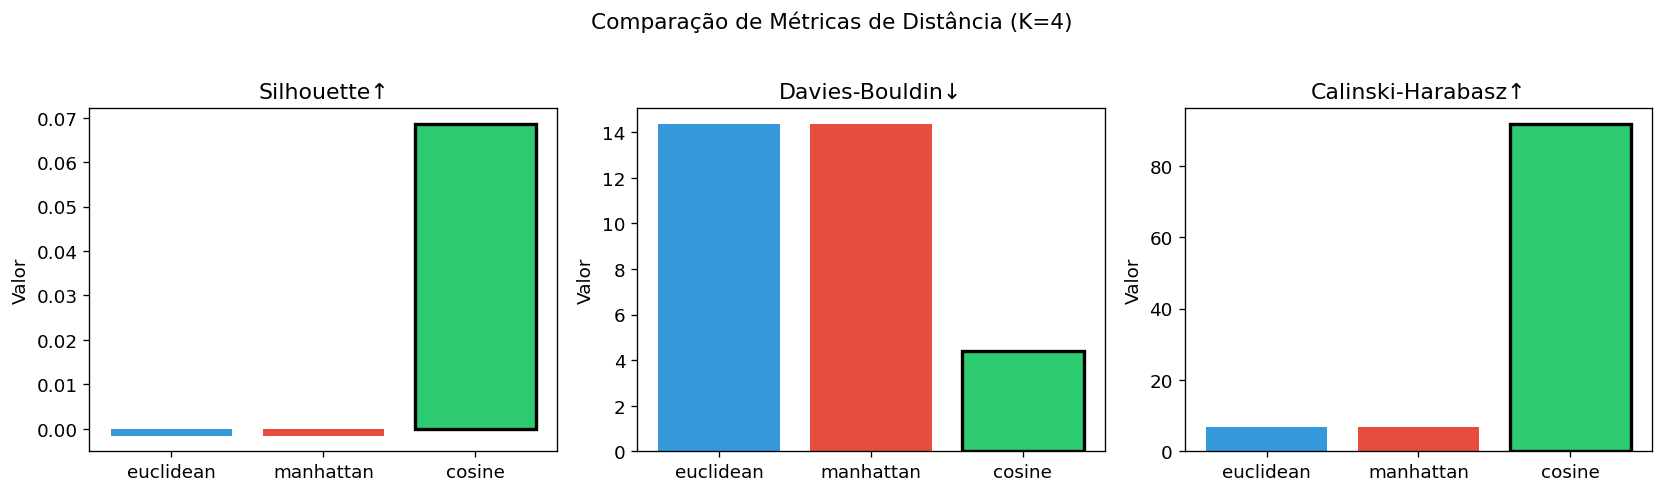


→ Métrica selecionada para K-Means/Hierárquico: Euclidiana (após StandardScaler)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, (col, ascending) in zip(axes, [
    ('Silhouette↑', False), ('Davies-Bouldin↓', True), ('Calinski-Harabasz↑', False)
]):
    vals = df_metrics[col]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(col)
    ax.set_ylabel('Valor')
    best = vals.idxmin() if ascending else vals.idxmax()
    for bar, name in zip(bars, vals.index):
        if name == best:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

plt.suptitle('Comparação de Métricas de Distância (K=4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('metric_comparison.png', bbox_inches='tight')
plt.show()
print('\n→ Métrica selecionada para K-Means/Hierárquico: Euclidiana (após StandardScaler)')

> **Decisão**: Apesar da cosseno ser superior neste teste, a metrica selecionada para K-Means/Hierárquico (foi feita considerando o pipeline padrão e mais robusto a alta dimensionalidade) e reservamos o cosseno para o DBSCAN.

---
## 4. K-Means: Seleção do K Ótimo

### 4.1 Método do Cotovelo (Elbow) + Silhouette Score

In [5]:
K_RANGE = range(2, 11)
inertias  = []
silhouettes = []
db_scores   = []
ch_scores   = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    labels = km.labels_
    # Silhouette em amostra (custo computacional)
    sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx], metric='euclidean')
    silhouettes.append(sil)
    db_scores.append(davies_bouldin_score(X_scaled[sample_idx], labels[sample_idx]))
    ch_scores.append(calinski_harabasz_score(X_scaled[sample_idx], labels[sample_idx]))
    print(f'K={k:2d} | Inertia={km.inertia_:.1f} | Sil={sil:.4f} | DB={db_scores[-1]:.4f} | CH={ch_scores[-1]:.1f}')

K= 2 | Inertia=4884009.5 | Sil=0.0034 | DB=10.9865 | CH=6.1
K= 3 | Inertia=4875273.5 | Sil=-0.0010 | DB=18.5877 | CH=6.2
K= 4 | Inertia=4866580.5 | Sil=-0.0046 | DB=13.7135 | CH=6.1
K= 5 | Inertia=4859703.0 | Sil=-0.0029 | DB=13.7945 | CH=6.0
K= 6 | Inertia=4852595.0 | Sil=-0.0112 | DB=13.4788 | CH=5.8
K= 7 | Inertia=4844546.5 | Sil=-0.0120 | DB=13.5491 | CH=5.6
K= 8 | Inertia=4835477.5 | Sil=-0.0124 | DB=12.4708 | CH=5.7
K= 9 | Inertia=4828157.5 | Sil=-0.0073 | DB=11.4953 | CH=5.9
K=10 | Inertia=4822117.5 | Sil=-0.0102 | DB=11.0718 | CH=5.5


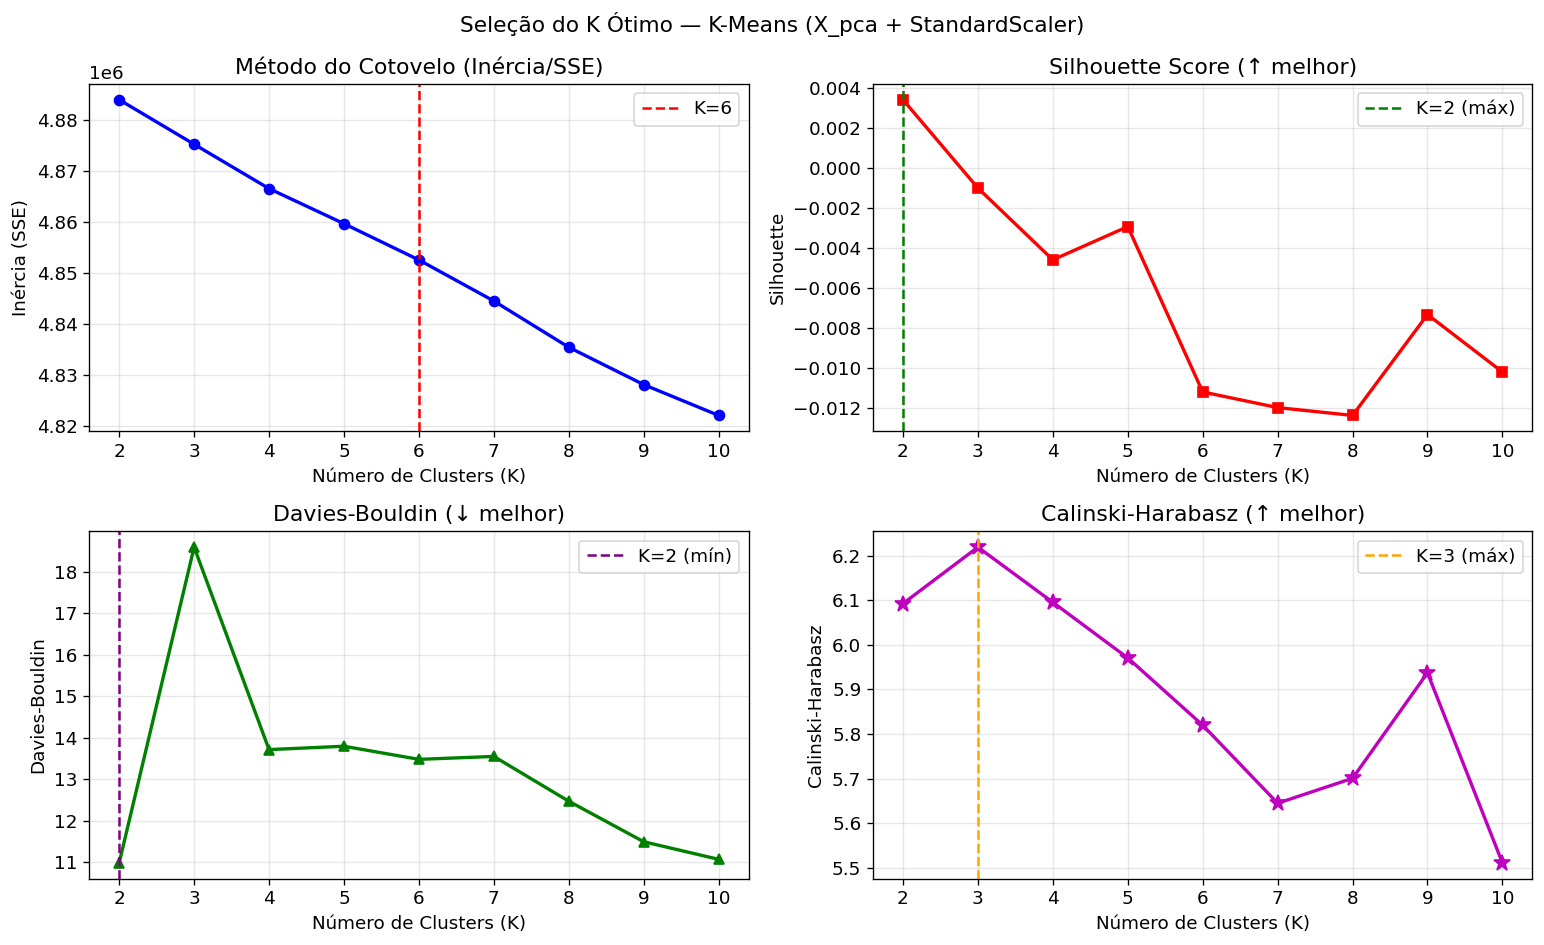

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ks = list(K_RANGE)

axes[0,0].plot(ks, inertias, 'bo-', linewidth=2)
axes[0,0].set_title('Método do Cotovelo (Inércia/SSE)')
axes[0,0].set_xlabel('Número de Clusters (K)')
axes[0,0].set_ylabel('Inércia (SSE)')
axes[0,0].axvline(x=6, color='red', linestyle='--', label='K=6')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ks, silhouettes, 'rs-', linewidth=2)
axes[0,1].set_title('Silhouette Score (↑ melhor)')
axes[0,1].set_xlabel('Número de Clusters (K)')
axes[0,1].set_ylabel('Silhouette')
axes[0,1].axvline(x=ks[np.argmax(silhouettes)], color='green', linestyle='--',
                  label=f'K={ks[np.argmax(silhouettes)]} (máx)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(ks, db_scores, 'g^-', linewidth=2)
axes[1,0].set_title('Davies-Bouldin (↓ melhor)')
axes[1,0].set_xlabel('Número de Clusters (K)')
axes[1,0].set_ylabel('Davies-Bouldin')
axes[1,0].axvline(x=ks[np.argmin(db_scores)], color='purple', linestyle='--',
                  label=f'K={ks[np.argmin(db_scores)]} (mín)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ks, ch_scores, 'm*-', linewidth=2, markersize=10)
axes[1,1].set_title('Calinski-Harabasz (↑ melhor)')
axes[1,1].set_xlabel('Número de Clusters (K)')
axes[1,1].set_ylabel('Calinski-Harabasz')
axes[1,1].axvline(x=ks[np.argmax(ch_scores)], color='orange', linestyle='--',
                  label=f'K={ks[np.argmax(ch_scores)]} (máx)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Seleção do K Ótimo — K-Means (X_pca + StandardScaler)', fontsize=13)
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', bbox_inches='tight')
plt.show()

A inércia cai de forma praticamente linear, sem cotovelo definido.
> A ausência de cotovelo significa que não existe uma estrutura de clusters compacta e bem separada.

> Silhouette negativo em K≥3 significa que, em média, os pontos estão mais próximos de clusters vizinhos do que do próprio cluster

> O K-Means está impondo partições artificiais em vez de descobrir agrupamentos naturais. Os embeddings destas notícias formam uma nuvem densa no espaço, indicando que os dados não se separam naturalmente de acordo com partições euclidianas.

### 4.2 Teste de Estabilidade (ARI entre seeds)

Rodamos K-Means com seeds `[0, 1, 2, 42, 100]` e calculamos o ARI normalizado entre todos os pares. Um ARI > 0.8 indica boa estabilidade.

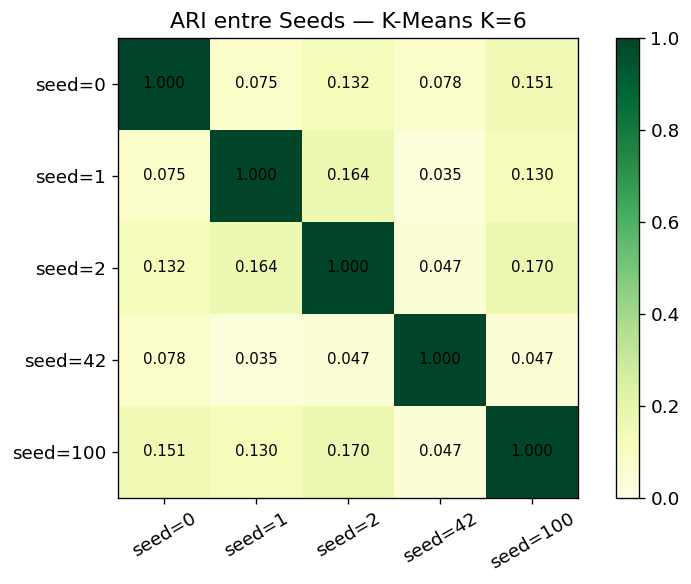

ARI médio entre pares (off-diagonal): 0.1029
ARI mínimo: 0.0351


In [7]:
SEEDS_TEST = [0, 1, 2, 42, 100]
K_BEST = 6  # Será ajustado pela análise acima

all_labels = {}
for s in SEEDS_TEST:
    km = KMeans(n_clusters=K_BEST, init='k-means++', n_init=10, random_state=s, max_iter=300)
    all_labels[s] = km.fit_predict(X_scaled)

ari_matrix = np.zeros((len(SEEDS_TEST), len(SEEDS_TEST)))
for i, s1 in enumerate(SEEDS_TEST):
    for j, s2 in enumerate(SEEDS_TEST):
        ari_matrix[i, j] = adjusted_rand_score(all_labels[s1], all_labels[s2])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ari_matrix, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(SEEDS_TEST)))
ax.set_yticks(range(len(SEEDS_TEST)))
ax.set_xticklabels([f'seed={s}' for s in SEEDS_TEST], rotation=30)
ax.set_yticklabels([f'seed={s}' for s in SEEDS_TEST])
for i in range(len(SEEDS_TEST)):
    for j in range(len(SEEDS_TEST)):
        ax.text(j, i, f'{ari_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9)
ax.set_title(f'ARI entre Seeds — K-Means K={K_BEST}')
plt.tight_layout()
plt.savefig('kmeans_stability.png', bbox_inches='tight')
plt.show()

off_diag = ari_matrix[np.triu_indices(len(SEEDS_TEST), k=1)]
print(f'ARI médio entre pares (off-diagonal): {off_diag.mean():.4f}')
print(f'ARI mínimo: {off_diag.min():.4f}')

O ARI médio de 0.1029 e mínimo de 0.0351 são muito abaixo do limiar esperado de 0.8. Isso significa que cada seed produz uma partição substancialmente diferente das demais — o K-Means não está convergindo para uma solução estável.

Esse resultado é coerente com a ausência de estrutura de clusters identificada na seção anterior. Quando os clusters não são compactos e bem separados, qualquer partição em K regiões é igualmente (i)válida, e o K-Means vai encontrar mínimos locais distintos dependendo da inicialização.
O k-means++ melhora a convergência por rodada, mas não resolve a ausência de estrutura global

### 4.3 K-Means Final com K Escolhido

In [8]:
km_final = KMeans(n_clusters=K_BEST, init='k-means++', n_init=20, random_state=SEED, max_iter=300)
km_labels = km_final.fit_predict(X_scaled)

df['kmeans_label'] = km_labels

# Métricas internas
km_sil = silhouette_score(X_scaled[sample_idx], km_labels[sample_idx], metric='euclidean')
km_db  = davies_bouldin_score(X_scaled[sample_idx], km_labels[sample_idx])
km_ch  = calinski_harabasz_score(X_scaled[sample_idx], km_labels[sample_idx])

# Métricas externas
km_ari_rating = adjusted_rand_score(y_rating, km_labels)
km_nmi_rating = normalized_mutual_info_score(y_rating, km_labels)
km_ari_source = adjusted_rand_score(y_source, km_labels)
km_nmi_source = normalized_mutual_info_score(y_source, km_labels)

print(f'=== K-Means (K={K_BEST}) ===')
print(f'Métricas internas (amostra 3000):')
print(f'  Silhouette: {km_sil:.4f}   (ref: ≥0.25 bom)')
print(f'  Davies-Bouldin: {km_db:.4f} (↓ melhor)')
print(f'  Calinski-Harabasz: {km_ch:.1f} (↑ melhor)')
print(f'\nMétricas externas (todo dataset):')
print(f'  ARI vs rating_norm: {km_ari_rating:.4f}')
print(f'  NMI vs rating_norm: {km_nmi_rating:.4f}')
print(f'  ARI vs source_name: {km_ari_source:.4f}')
print(f'  NMI vs source_name: {km_nmi_source:.4f}')

=== K-Means (K=6) ===
Métricas internas (amostra 3000):
  Silhouette: -0.0085   (ref: ≥0.25 bom)
  Davies-Bouldin: 14.5448 (↓ melhor)
  Calinski-Harabasz: 5.6 (↑ melhor)

Métricas externas (todo dataset):
  ARI vs rating_norm: 0.0442
  NMI vs rating_norm: 0.0611
  ARI vs source_name: 0.0410
  NMI vs source_name: 0.0529


**Sobre as Métricas Internas** elas confirmam a extrema sobreposição dos dados. O Silhouette Score de -0.0085 encontra-se muito abaixo da referência inicial de viabilidade técnica (≥ 0.25). Em conjunto com um índice Davies-Bouldin alto (14.5) e um Calinski-Harabasz irrelevante (5.6), constata-se a ausência total de coesão e separação. O K-Means fragmentou o espaço de embeddings de forma arbitrária.

**Sobre as Métricas Externas** o ARI vs. rating_norm (0.0442) e ARI vs. source_name (0.0410) são virtualmente iguais e ambos próximos de zero. A concordância entre os agrupamentos encontrados e as classes reais é equiparável ao acaso. Os clusters K-Means não correspondem nem às classes semânticas nem às agências de origem de forma relevante.

### 4.4 Análise de Pureza dos Clusters K-Means

Verificamos tanto a pureza por `rating_norm` quanto por `source_name`, visto que a agência "boatos" que possui 47,8% dos dados e 100% dele são classificados como `falso`, pode ser um confundidor forte.

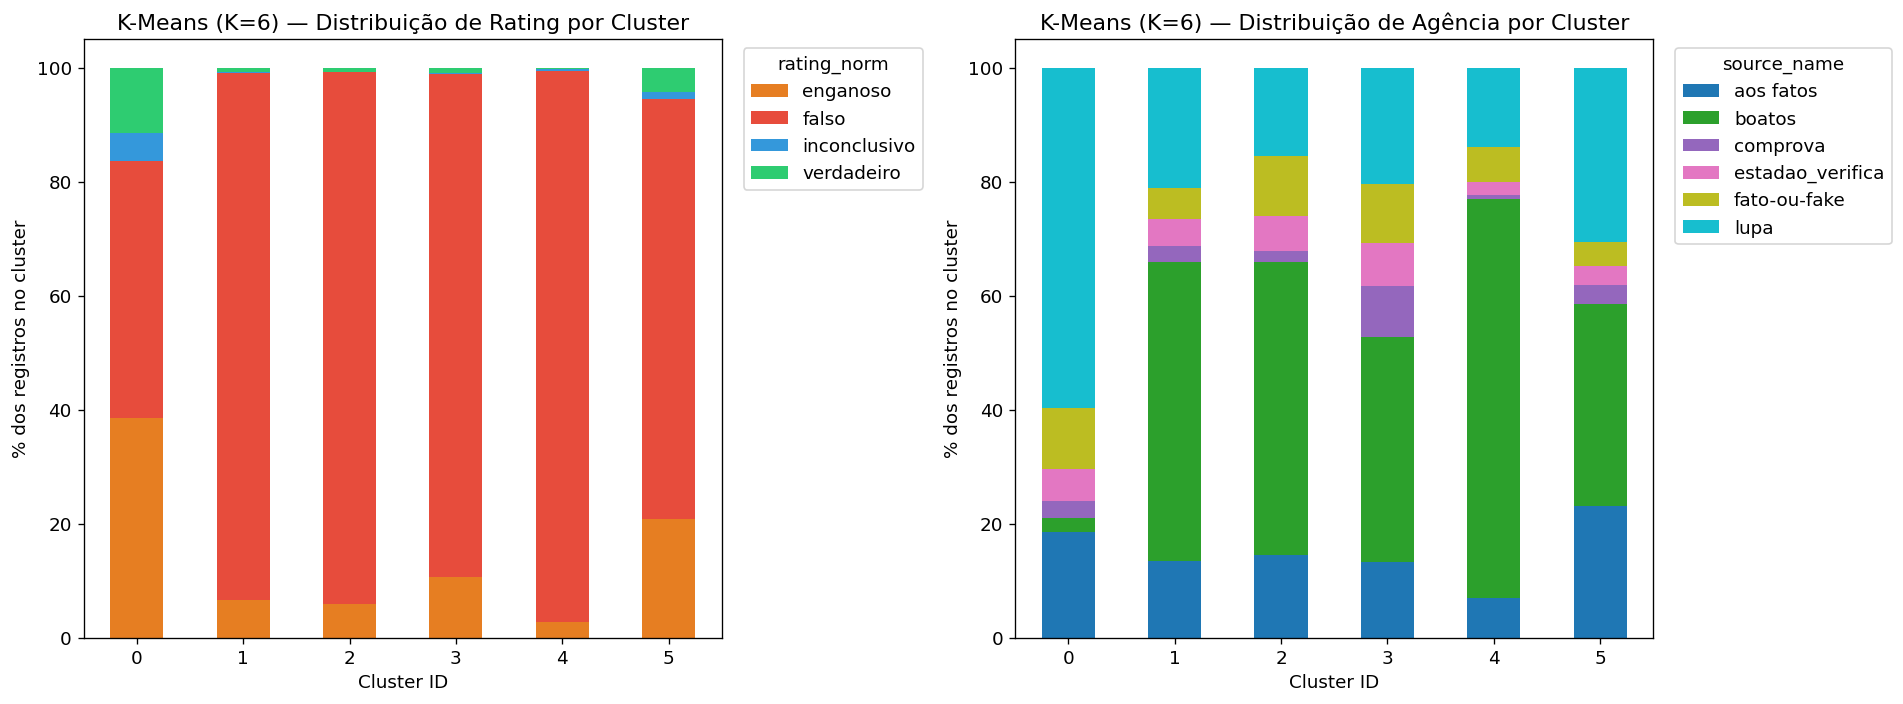

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pureza por rating_norm ---
purity_rating = pd.crosstab(df['kmeans_label'], df['rating_norm'], normalize='index') * 100
purity_rating.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[LABEL_COLORS_RATING.get(c, '#95a5a6') for c in purity_rating.columns])
axes[0].set_title(f'K-Means (K={K_BEST}) — Distribuição de Rating por Cluster')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('% dos registros no cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='rating_norm', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- Pureza por source_name ---
purity_source = pd.crosstab(df['kmeans_label'], df['source_name'], normalize='index') * 100
purity_source.plot(kind='bar', stacked=True, ax=axes[1],
                   colormap='tab10')
axes[1].set_title(f'K-Means (K={K_BEST}) — Distribuição de Agência por Cluster')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('% dos registros no cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='source_name', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('kmeans_purity.png', bbox_inches='tight')
plt.show()

In [10]:
# Tamanho de cada cluster
cluster_sizes = df['kmeans_label'].value_counts().sort_index()
print('Tamanho dos clusters K-Means:')
print(cluster_sizes)
print(f'\nMaior cluster: {cluster_sizes.max()} amostras ({cluster_sizes.max()/len(df)*100:.1f}%)')
print(f'Menor cluster: {cluster_sizes.min()} amostras ({cluster_sizes.min()/len(df)*100:.1f}%)')

Tamanho dos clusters K-Means:
kmeans_label
0     882
1    3752
2    3106
3    1562
4    1521
5     716
Name: count, dtype: int64

Maior cluster: 3752 amostras (32.5%)
Menor cluster: 716 amostras (6.2%)


A distribuição é bastante desequilibrada: o maior cluster tem 32,5% dos dados e o menor apenas 6,2%. Essa assimetria, combinada com o Silhouette negativo, confirma que o K-Means está formando clusters de tamanhos arbitrários sem separabilidade real.

### 4.5 Visualização dos Clusters K-Means no UMAP 2D

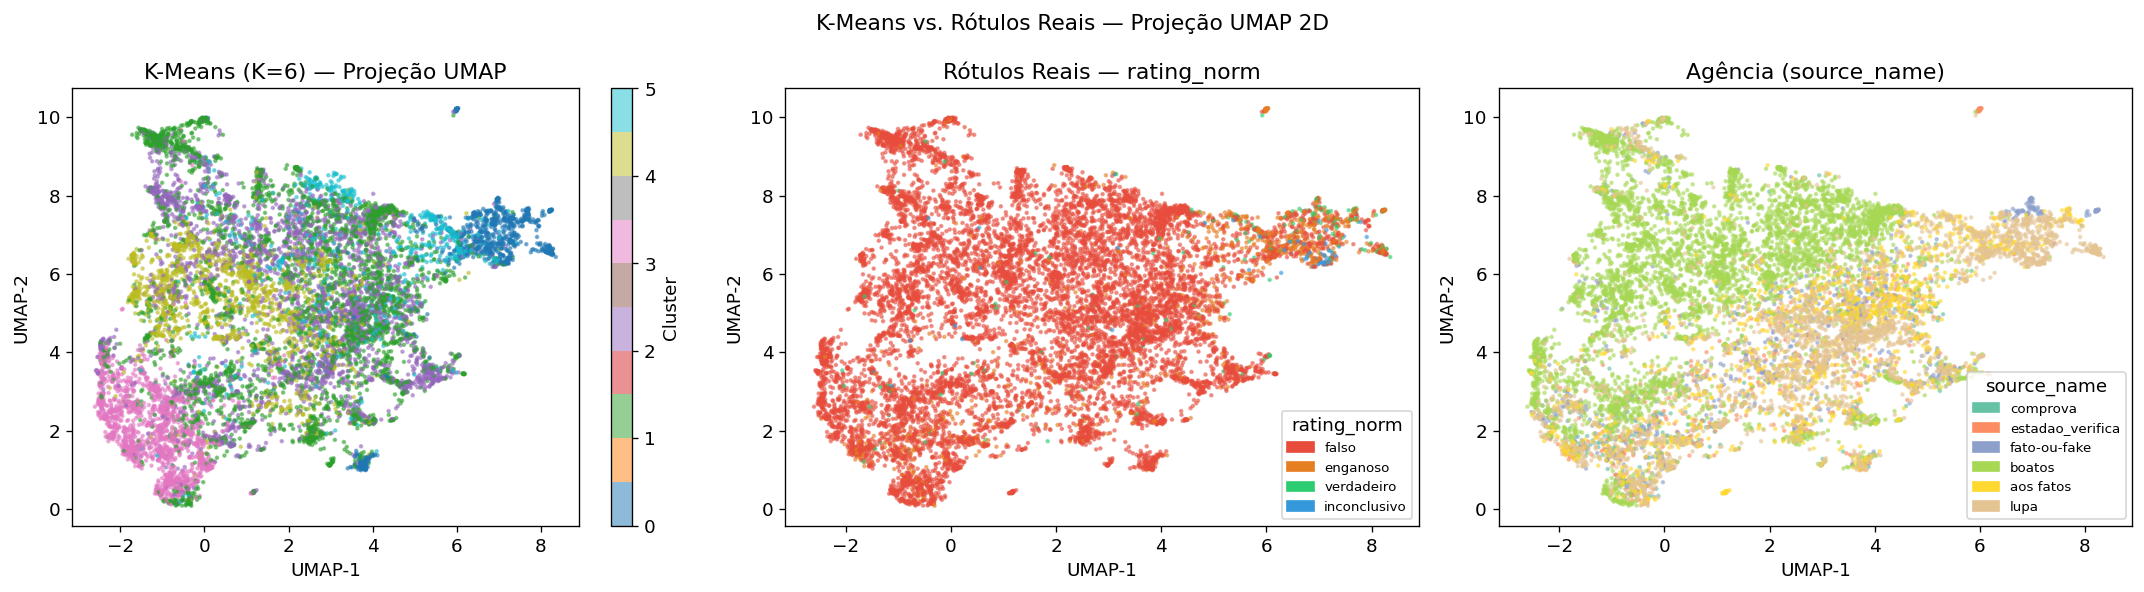

In [11]:
cmap_k = plt.cm.get_cmap('tab10', K_BEST)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Clusters K-Means
sc1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=km_labels,
                       cmap='tab10', s=3, alpha=0.5, vmin=0, vmax=K_BEST-1)
axes[0].set_title(f'K-Means (K={K_BEST}) — Projeção UMAP')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# Plot 2: rating_norm real
rating_colors = [LABEL_COLORS_RATING[r] for r in df['rating_norm']]
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=rating_colors, s=3, alpha=0.5)
patches = [mpatches.Patch(color=v, label=k) for k, v in LABEL_COLORS_RATING.items()]
axes[1].legend(handles=patches, title='rating_norm', fontsize=8)
axes[1].set_title('Rótulos Reais — rating_norm')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

# Plot 3: Agência (source_name)
sources = df['source_name'].unique()
color_map_s = {s: plt.cm.Set2(i / len(sources)) for i, s in enumerate(sources)}
source_colors = [color_map_s[s] for s in df['source_name']]
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=source_colors, s=3, alpha=0.5)
patches_s = [mpatches.Patch(color=v, label=k) for k, v in color_map_s.items()]
axes[2].legend(handles=patches_s, title='source_name', fontsize=8)
axes[2].set_title('Agência (source_name)')
axes[2].set_xlabel('UMAP-1')
axes[2].set_ylabel('UMAP-2')

plt.suptitle('K-Means vs. Rótulos Reais — Projeção UMAP 2D', fontsize=13)
plt.tight_layout()
plt.savefig('kmeans_umap.png', bbox_inches='tight')
plt.show()

Os clusters K-Means capturam diferenciação temática/temporal parcial, mas não separação por veracidade. As classes de rating são misturadas em proporções similares ao dataset original em quase todos os clusters (dominância de falso).

---
## 5. Agrupamento Hierárquico (Aglomerativo)

### 5.1 Motivação

O algoritmo hierárquico não requer K pré-definido e permite visualizar a estrutura de agrupamento via dendrograma. Usamos uma **amostra estratificada** de 1.500 pontos (proporcional ao `rating_norm`) para viabilizar o cálculo — o complexidade é O(n² log n).

Testamos três linkages:
- **Ward**: minimiza variância intra-cluster (boa separação)
- **Complete (MAX)**: tende a clusters compactos
- **Average**: balanço entre Ward e Single

In [12]:
# Amostra estratificada por rating_norm
np.random.seed(SEED)
HIER_N = 1500

strat_idx = []
for cls in df['rating_norm'].unique():
    cls_idx = df.index[df['rating_norm'] == cls].tolist()
    n_cls = max(1, int(HIER_N * len(cls_idx) / len(df)))
    chosen = np.random.choice(cls_idx, size=min(n_cls, len(cls_idx)), replace=False)
    strat_idx.extend(chosen)

strat_idx = np.array(strat_idx)
X_hier = X_scaled[strat_idx]
y_hier_rating = y_rating[strat_idx]
y_hier_source = y_source[strat_idx]

print(f'Amostra para hierárquico: {len(strat_idx)} pontos')
print('Distribuição na amostra:')
print(df['rating_norm'].iloc[strat_idx].value_counts())

Amostra para hierárquico: 1498 pontos
Distribuição na amostra:
rating_norm
falso           1318
enganoso         146
verdadeiro        26
inconclusivo       8
Name: count, dtype: int64


In [13]:
# Calcular linkages
print('Calculando linkages (pode levar ~30s)...')
Z_ward     = linkage(X_hier, method='ward',     metric='euclidean')
Z_complete = linkage(X_hier, method='complete',  metric='euclidean')
Z_average  = linkage(X_hier, method='average',   metric='euclidean')
print('Concluído.')

# Coeficiente cofenético
for name, Z in [('Ward', Z_ward), ('Complete', Z_complete), ('Average', Z_average)]:
    c, _ = cophenet(Z, pdist(X_hier))
    print(f'  Coeficiente Cofenético [{name}]: {c:.4f}  (próximo de 1 = melhor preservação)')

Calculando linkages (pode levar ~30s)...
Concluído.
  Coeficiente Cofenético [Ward]: 0.2567  (próximo de 1 = melhor preservação)
  Coeficiente Cofenético [Complete]: 0.6076  (próximo de 1 = melhor preservação)
  Coeficiente Cofenético [Average]: 0.8323  (próximo de 1 = melhor preservação)


### 5.2 Dendrograma Comparativo

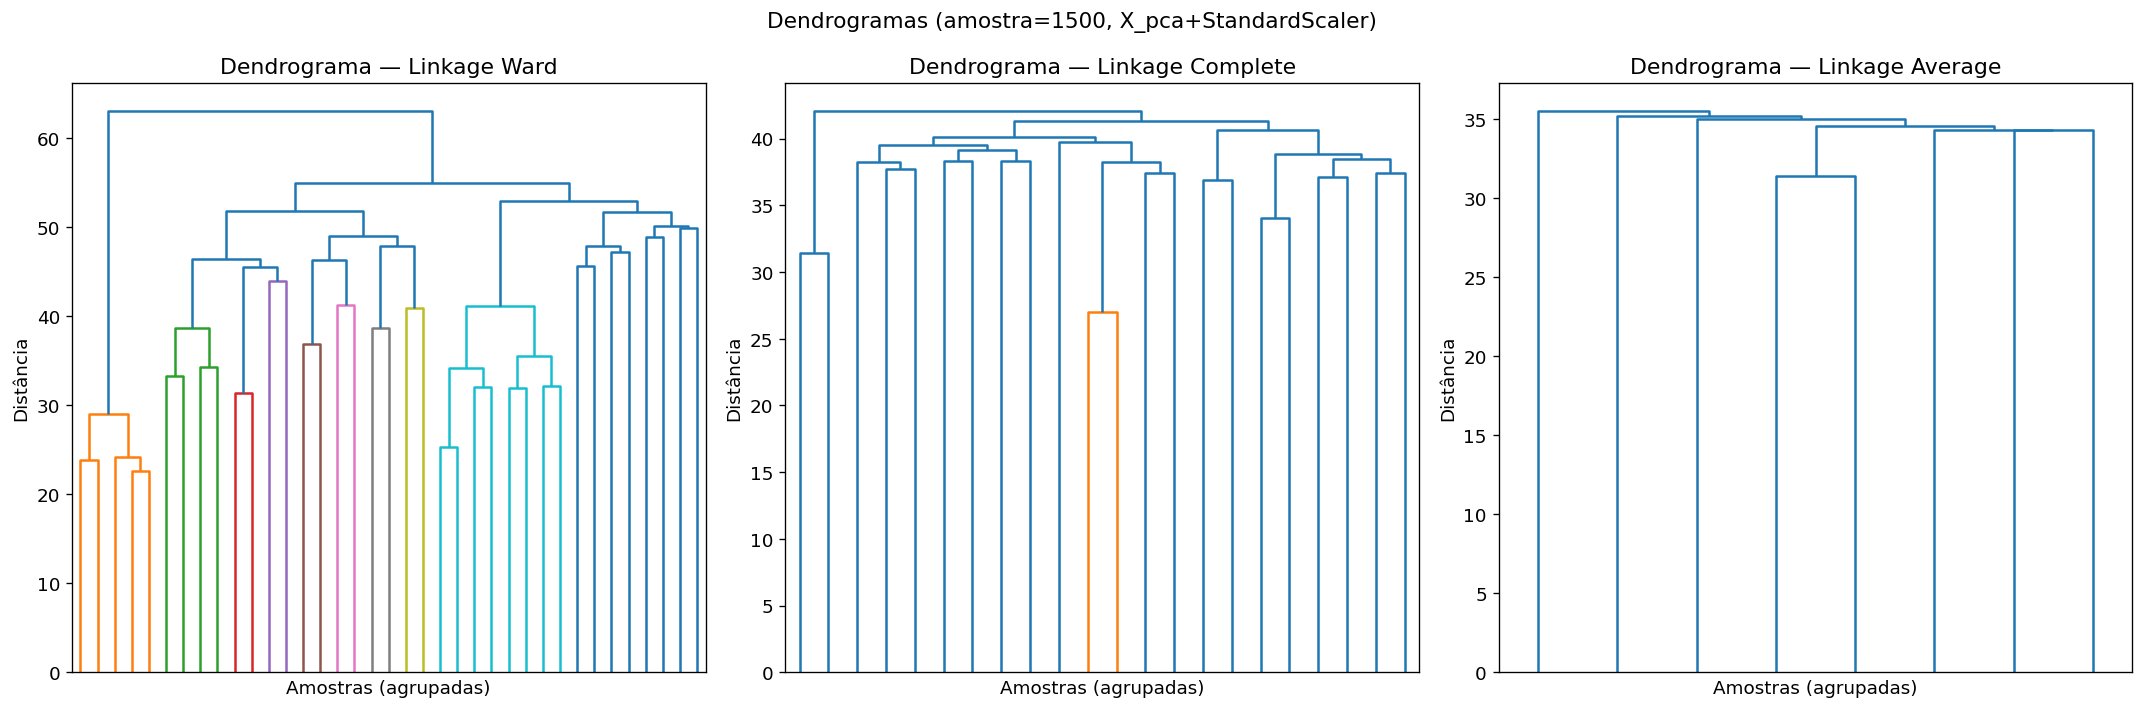

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, Z) in zip(axes, [('Ward', Z_ward), ('Complete', Z_complete), ('Average', Z_average)]):
    dendrogram(Z, ax=ax, truncate_mode='level', p=5,
               show_leaf_counts=True, no_labels=True,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrograma — Linkage {name}')
    ax.set_xlabel('Amostras (agrupadas)')
    ax.set_ylabel('Distância')

plt.suptitle('Dendrogramas (amostra=1500, X_pca+StandardScaler)', fontsize=13)
plt.tight_layout()
plt.savefig('dendrograms.png', bbox_inches='tight')
plt.show()

### 5.3 Corte do Dendrograma — Seleção de K

In [15]:
# Avaliar Ward com diferentes K
hier_results = {}
for k in [2, 3, 4, 5, 6, 7, 8]:
    labels_hier = fcluster(Z_ward, k, criterion='maxclust') - 1
    sil = silhouette_score(X_hier, labels_hier, metric='euclidean')
    db  = davies_bouldin_score(X_hier, labels_hier)
    ari = adjusted_rand_score(y_hier_rating, labels_hier)
    ari_s = adjusted_rand_score(y_hier_source, labels_hier)
    hier_results[k] = {
        'Silhouette': sil, 'Davies-Bouldin': db,
        'ARI_rating': ari, 'ARI_source': ari_s
    }
    print(f'K={k} | Sil={sil:.4f} | DB={db:.4f} | ARI_rating={ari:.4f} | ARI_source={ari_s:.4f}')

df_hier = pd.DataFrame(hier_results).T
K_HIER = df_hier['Silhouette'].idxmax()
print(f'\n→ K selecionado para hierárquico (Ward): {K_HIER}')

K=2 | Sil=0.1158 | DB=1.8119 | ARI_rating=-0.0058 | ARI_source=0.0032
K=3 | Sil=0.0582 | DB=6.5898 | ARI_rating=-0.0356 | ARI_source=-0.0077
K=4 | Sil=0.0579 | DB=5.9249 | ARI_rating=-0.0451 | ARI_source=-0.0101
K=5 | Sil=0.0539 | DB=5.1248 | ARI_rating=-0.0458 | ARI_source=-0.0105
K=6 | Sil=0.0011 | DB=8.2366 | ARI_rating=-0.0204 | ARI_source=0.0103
K=7 | Sil=0.0015 | DB=8.2569 | ARI_rating=0.0062 | ARI_source=0.0098
K=8 | Sil=-0.0004 | DB=7.9308 | ARI_rating=-0.0048 | ARI_source=-0.0041

→ K selecionado para hierárquico (Ward): 2


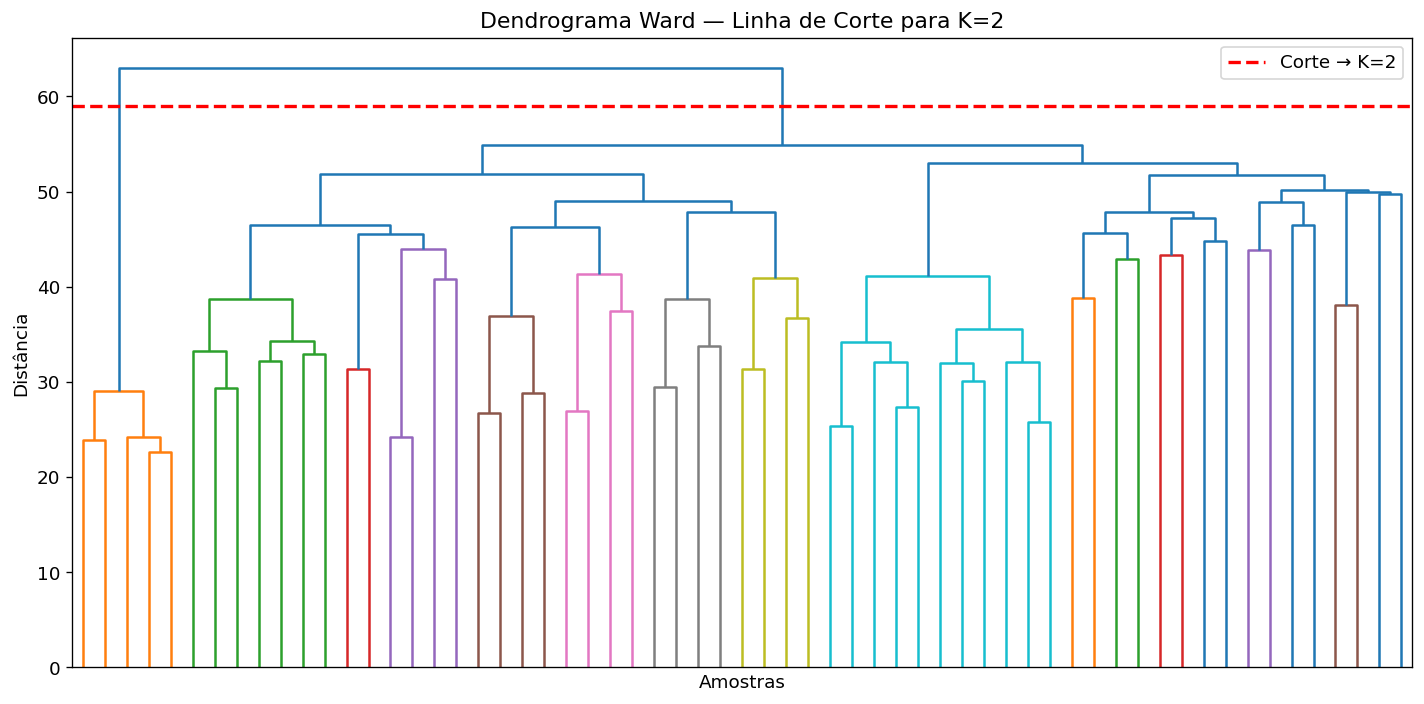

In [16]:
# Dendrograma Ward com linha de corte
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z_ward, ax=ax, truncate_mode='level', p=6,
           show_leaf_counts=True, no_labels=True)

# Linha de corte para K_HIER clusters
# Encontrar a altura de corte
sorted_distances = np.sort(Z_ward[:, 2])[::-1]
cut_height = (sorted_distances[K_HIER - 2] + sorted_distances[K_HIER - 1]) / 2
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2, label=f'Corte → K={K_HIER}')
ax.legend(fontsize=11)
ax.set_title(f'Dendrograma Ward — Linha de Corte para K={K_HIER}')
ax.set_xlabel('Amostras')
ax.set_ylabel('Distância')
plt.tight_layout()
plt.savefig('dendrogram_cut.png', bbox_inches='tight')
plt.show()

K=2 é o corte natural do dendrograma: O Ward identifica uma separação principal em dois grupos. Dado o domínio da agência boatos (47,8% dos dados, 100% falso), a hipótese mais provável é que K=2 separa os registros da boatos (cluster volumoso, pureza extrema em falso) dos registros das demais agências (cluster diverso, mix de ratings).

> O ARI negativo para K≥3 é notável: valores negativos de ARI indicam que a partição é pior do que aleatória — os clusters criados têm composição de classes mais heterogênea do que o esperado por acaso. Isso confirma que aumentar K no hierárquico cria clusters sem sentido semântico.

### 5.4 Visualização dos Clusters Hierárquicos

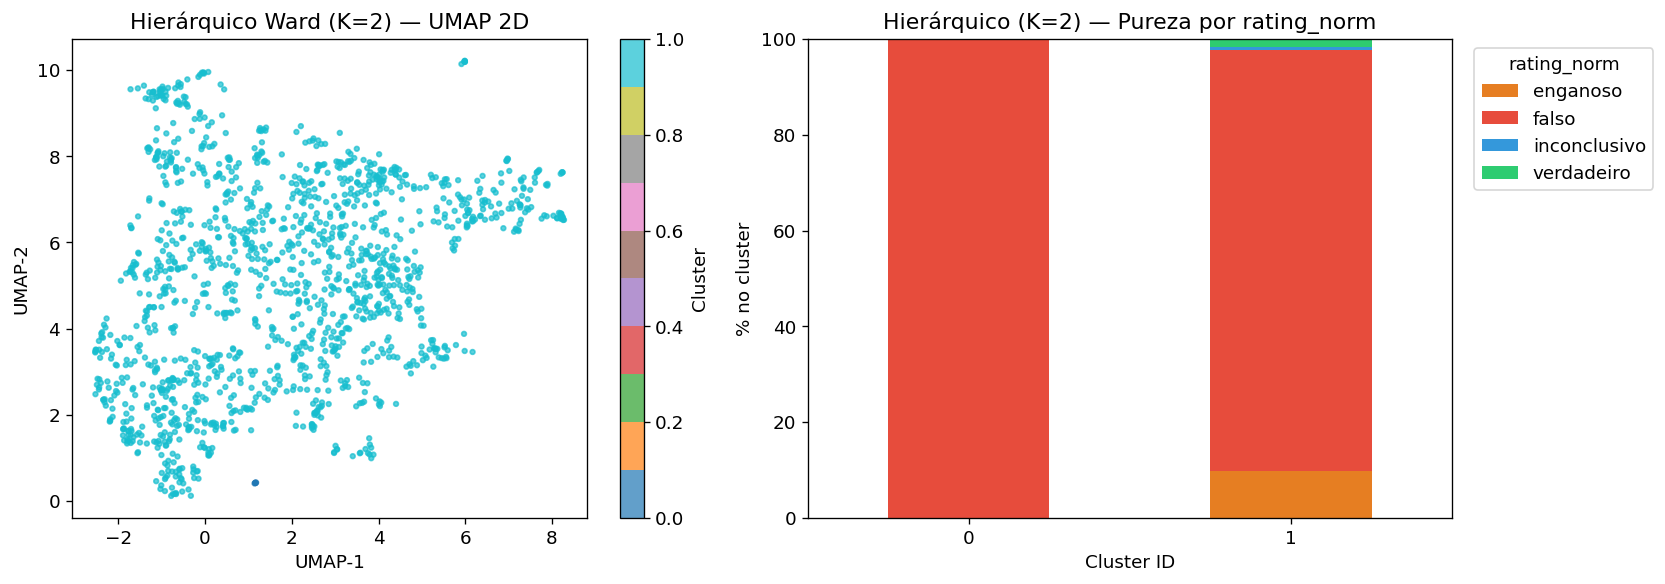

=== Hierárquico Ward (K=2, amostra=1498) ===
Silhouette:      0.1158
Davies-Bouldin:  1.8119
ARI vs rating:   -0.0058
ARI vs source:   0.0032


In [17]:
labels_hier_best = fcluster(Z_ward, K_HIER, criterion='maxclust') - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UMAP com clusters hierárquicos
sc = axes[0].scatter(X_umap[strat_idx, 0], X_umap[strat_idx, 1],
                      c=labels_hier_best, cmap='tab10', s=8, alpha=0.7,
                      vmin=0, vmax=K_HIER - 1)
plt.colorbar(sc, ax=axes[0], label='Cluster')
axes[0].set_title(f'Hierárquico Ward (K={K_HIER}) — UMAP 2D')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# Pureza por rating_norm na amostra
df_hier_sample = df.iloc[strat_idx].copy()
df_hier_sample['hier_label'] = labels_hier_best
purity_hier = pd.crosstab(df_hier_sample['hier_label'], df_hier_sample['rating_norm'],
                           normalize='index') * 100
purity_hier.plot(kind='bar', stacked=True, ax=axes[1],
                 color=[LABEL_COLORS_RATING.get(c, '#95a5a6') for c in purity_hier.columns])
axes[1].set_title(f'Hierárquico (K={K_HIER}) — Pureza por rating_norm')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('% no cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='rating_norm', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('hierarchical_results.png', bbox_inches='tight')
plt.show()

print(f'=== Hierárquico Ward (K={K_HIER}, amostra={len(strat_idx)}) ===')
print(f'Silhouette:      {silhouette_score(X_hier, labels_hier_best):.4f}')
print(f'Davies-Bouldin:  {davies_bouldin_score(X_hier, labels_hier_best):.4f}')
print(f'ARI vs rating:   {adjusted_rand_score(y_hier_rating, labels_hier_best):.4f}')
print(f'ARI vs source:   {adjusted_rand_score(y_hier_source, labels_hier_best):.4f}')

---
## 6. DBSCAN — Agrupamento por Densidade

### 6.1 Motivação

DBSCAN detecta clusters de forma arbitrária e identifica **outliers** (pontos de ruído) automaticamente. Operamos sobre `X_l2` (L2-normalizado) com `metric='cosine'` para capturar direção semântica dos embeddings, ignorando magnitude.

**Hiperparâmetros:**
- `eps`: raio de vizinhança — estimado pelo gráfico k-dist
- `min_samples`: mínimo de pontos para formar um core point

> Usamos amostra de 5.000 pontos para viabilizar o tunning inicial.

Distribuição das distâncias ao 5o vizinho (cosseno):
  p10: 0.6533
  p25: 0.6160
  p50: 0.5728
  p75: 0.5240
  p90: 0.4741


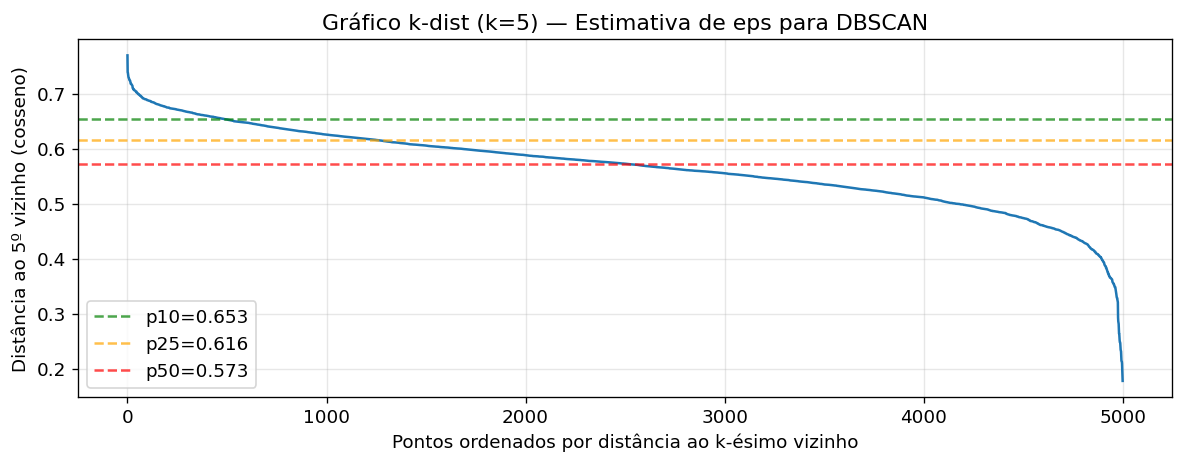

In [18]:
from sklearn.neighbors import NearestNeighbors

np.random.seed(SEED)
DBSCAN_N = 5000
dbscan_idx = np.random.choice(len(X_l2), size=DBSCAN_N, replace=False)
X_db = X_l2[dbscan_idx]
y_db_rating = y_rating[dbscan_idx]
y_db_source = y_source[dbscan_idx]

# Gráfico k-dist para estimar eps (k=5)
# IMPORTANTE: embeddings BERT L2-normalizados têm distâncias cosseno na faixa 0.54–0.82
# O eps deve estar nessa faixa, não em 0.05–0.20 como seria em outros domínios.
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn + 1, metric='cosine', algorithm='brute').fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
k_distances = np.sort(distances[:, k_nn])[::-1]

print('Distribuição das distâncias ao 5o vizinho (cosseno):')
for p in [10, 25, 50, 75, 90]:
    print(f'  p{p}: {np.percentile(k_distances, 100-p):.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.5)
ax.set_title(f'Gráfico k-dist (k={k_nn}) — Estimativa de eps para DBSCAN')
ax.set_xlabel('Pontos ordenados por distância ao k-ésimo vizinho')
ax.set_ylabel(f'Distância ao {k_nn}º vizinho (cosseno)')

# Marcar percentis como referência para escolha de eps
for pct, color in [(10, 'green'), (25, 'orange'), (50, 'red')]:
    val = np.percentile(k_distances, 100 - pct)
    ax.axhline(y=val, linestyle='--', alpha=0.7, color=color, label=f'p{pct}={val:.3f}')

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdist.png', bbox_inches='tight')
plt.show()


### 6.2 Grid Search de Hiperparâmetros DBSCAN

In [19]:
# Distâncias cosseno em embeddings BERT L2-normalizados ficam na faixa 0.54–0.82.
# O joelho do k-dist costuma aparecer entre p10 e p25 das distâncias.
eps_values = [0.56, 0.60, 0.63, 0.66, 0.70, 0.75]
min_samples_values = [5, 10, 20]

dbscan_grid = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms, metric='cosine', algorithm='brute')
        labels_db = db.fit_predict(X_db)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        noise_pct = n_noise / len(labels_db) * 100

        if n_clusters >= 2 and n_noise < len(labels_db) * 0.8:
            valid_mask = labels_db != -1
            sil = silhouette_score(X_db[valid_mask], labels_db[valid_mask], metric='cosine')
            ari = adjusted_rand_score(y_db_rating[valid_mask], labels_db[valid_mask])
        else:
            sil, ari = None, None

        dbscan_grid.append({
            'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
            'noise_pct': noise_pct, 'silhouette': sil, 'ARI_rating': ari
        })
        print(f'eps={eps:.2f} ms={ms:2d} | clusters={n_clusters:3d} | noise={noise_pct:.1f}% | sil={sil}')

df_dbgrid = pd.DataFrame(dbscan_grid)
print('\nMelhor combinação (maior Silhouette com ≥2 clusters):')
valid = df_dbgrid[df_dbgrid['silhouette'].notna()]
if len(valid) > 0:
    best = valid.loc[valid['silhouette'].idxmax()]
    print(best)
else:
    print('Nenhuma combinação válida — usando padrão eps=0.63, ms=5')
    best = pd.Series({'eps': 0.63, 'min_samples': 5})


eps=0.56 ms= 5 | clusters=  9 | noise=24.6% | sil=-0.10365269333124161
eps=0.56 ms=10 | clusters=  7 | noise=41.4% | sil=-0.0844934731721878
eps=0.56 ms=20 | clusters=  4 | noise=62.4% | sil=0.030319644138216972
eps=0.60 ms= 5 | clusters=  2 | noise=9.6% | sil=-0.0007140076486393809
eps=0.60 ms=10 | clusters=  3 | noise=16.1% | sil=-0.0440211147069931
eps=0.60 ms=20 | clusters=  1 | noise=32.2% | sil=None
eps=0.63 ms= 5 | clusters=  1 | noise=3.2% | sil=None
eps=0.63 ms=10 | clusters=  1 | noise=5.6% | sil=None
eps=0.63 ms=20 | clusters=  1 | noise=12.8% | sil=None
eps=0.66 ms= 5 | clusters=  1 | noise=0.7% | sil=None
eps=0.66 ms=10 | clusters=  1 | noise=1.2% | sil=None
eps=0.66 ms=20 | clusters=  1 | noise=2.9% | sil=None
eps=0.70 ms= 5 | clusters=  1 | noise=0.1% | sil=None
eps=0.70 ms=10 | clusters=  1 | noise=0.1% | sil=None
eps=0.70 ms=20 | clusters=  1 | noise=0.2% | sil=None
eps=0.75 ms= 5 | clusters=  1 | noise=0.0% | sil=None
eps=0.75 ms=10 | clusters=  1 | noise=0.0% | sil=N

In [20]:
# Parâmetros selecionados
EPS_BEST = best['eps'] if len(valid) > 0 else 0.10
MS_BEST  = int(best['min_samples']) if len(valid) > 0 else 10

print(f'Parâmetros DBSCAN: eps={EPS_BEST}, min_samples={MS_BEST}')

db_final = DBSCAN(eps=EPS_BEST, min_samples=MS_BEST, metric='cosine', algorithm='brute')
db_labels = db_final.fit_predict(X_db)

n_clust_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()
mask_valid = db_labels != -1

print(f'\n=== DBSCAN Final (amostra={DBSCAN_N}) ===')
print(f'Clusters encontrados: {n_clust_db}')
print(f'Outliers (ruído):     {n_noise_db} ({n_noise_db/DBSCAN_N*100:.1f}%)')

if mask_valid.sum() >= 10:
    db_sil = silhouette_score(X_db[mask_valid], db_labels[mask_valid], metric='cosine')
    db_db  = davies_bouldin_score(X_db[mask_valid], db_labels[mask_valid])
    db_ari = adjusted_rand_score(y_db_rating[mask_valid], db_labels[mask_valid])
    db_nmi = normalized_mutual_info_score(y_db_rating[mask_valid], db_labels[mask_valid])
    db_ari_s = adjusted_rand_score(y_db_source[mask_valid], db_labels[mask_valid])
    print(f'Silhouette (sem ruído):  {db_sil:.4f}')
    print(f'Davies-Bouldin:          {db_db:.4f}')
    print(f'ARI vs rating_norm:      {db_ari:.4f}')
    print(f'NMI vs rating_norm:      {db_nmi:.4f}')
    print(f'ARI vs source_name:      {db_ari_s:.4f}')

Parâmetros DBSCAN: eps=0.56, min_samples=20

=== DBSCAN Final (amostra=5000) ===
Clusters encontrados: 4
Outliers (ruído):     3119 (62.4%)
Silhouette (sem ruído):  0.0303
Davies-Bouldin:          2.9829
ARI vs rating_norm:      -0.1210
NMI vs rating_norm:      0.0485
ARI vs source_name:      0.0260


### Diagnóstico do DBSCAN

A análise Grid Search do algoritmo DBSCAN corrobora definitivamente os diagnósticos obtidos pelo K-Means e pela projeção UMAP: **não existe estrutura natural de clusters separáveis nestes embeddings textuais.**

1. **À esquerda do limiar de densidade (eps < 0.60):** O algoritmo identifica múltiplos pequenos aglomerados, mas com um *Silhouette* negativo e taxas de ruído altíssimas. Geometricamente, o DBSCAN está a fragmentar zonas marginalmente mais densas de uma nuvem contínua, gerando partições artificiais (como evidenciado pelo *Silhouette*).
2. **O Colapso Dimensional (eps > 0.63):** Ao aumentar ligeiramente o raio de vizinhança, ocorre a fusão total. Quase 100% dos dados são absorvidos num único "megacluster". Esta transição abrupta prova que os dados formam um espaço contínuo sem "vales" vazios que separem grupos semânticos.

**A (Falsa) Melhor Combinação (eps=0.56, min_samples=20):**
Embora apresente a melhor métrica interna relativa (4 clusters, *Silhouette* de 0.0303):

* **Taxa de Ruído (62,4%):** O algoritmo considerou quase dois terços do *dataset* como "ruído" (outliers). Num espaço de alta dimensionalidade, isso indica que apenas uma pequena porção central dos dados possui densidade suficiente para formar um núcleo, enquanto a vasta maioria forma uma "coroa esparsa".


### 6.3 Visualização DBSCAN

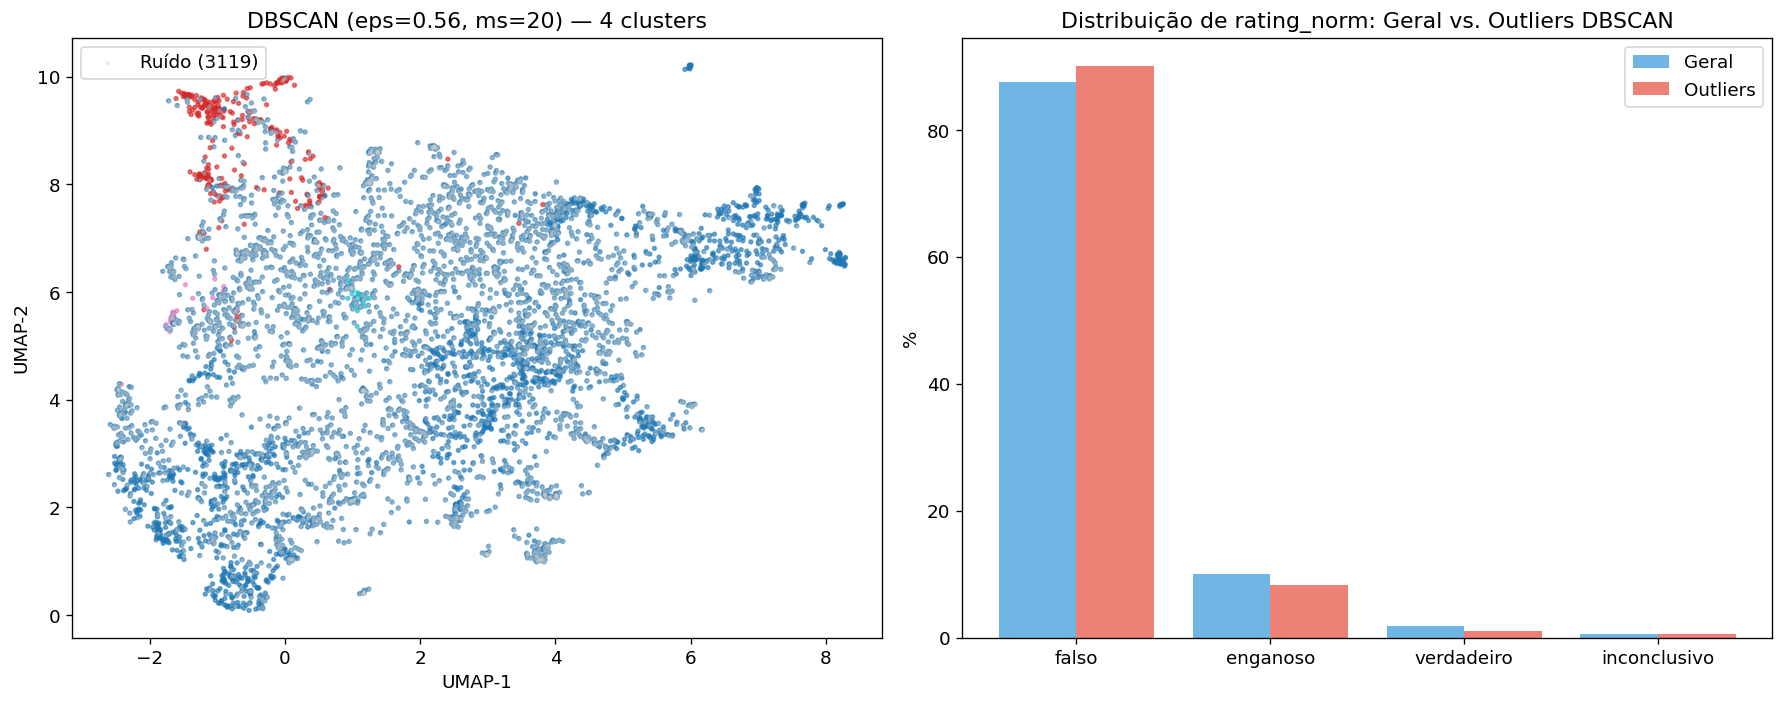

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Clusters DBSCAN
unique_labels = sorted(set(db_labels))
colors_db = ['#bdc3c7' if l == -1 else plt.cm.tab10(i / max(1, n_clust_db))
             for i, l in enumerate(db_labels)]

axes[0].scatter(X_umap[dbscan_idx, 0], X_umap[dbscan_idx, 1],
                c=db_labels, cmap='tab10', s=5, alpha=0.6,
                vmin=0, vmax=max(1, n_clust_db - 1))
# Destacar ruído em cinza
noise_mask_plot = db_labels == -1
axes[0].scatter(X_umap[dbscan_idx[noise_mask_plot], 0],
                X_umap[dbscan_idx[noise_mask_plot], 1],
                c='#cccccc', s=3, alpha=0.3, label=f'Ruído ({n_noise_db})')
axes[0].set_title(f'DBSCAN (eps={EPS_BEST}, ms={MS_BEST}) — {n_clust_db} clusters')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')
axes[0].legend()

# Distribuição dos outliers por rating_norm
df_db_sample = df.iloc[dbscan_idx].copy()
df_db_sample['db_label'] = db_labels
noise_by_rating = df_db_sample[df_db_sample['db_label'] == -1]['rating_norm'].value_counts(normalize=True) * 100
total_by_rating = df_db_sample['rating_norm'].value_counts(normalize=True) * 100

x = np.arange(len(noise_by_rating))
axes[1].bar(x - 0.2, total_by_rating[noise_by_rating.index], width=0.4,
            label='Geral', color='#3498db', alpha=0.7)
axes[1].bar(x + 0.2, noise_by_rating.values, width=0.4,
            label='Outliers', color='#e74c3c', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(noise_by_rating.index)
axes[1].set_title('Distribuição de rating_norm: Geral vs. Outliers DBSCAN')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.savefig('dbscan_results.png', bbox_inches='tight')
plt.show()

---
## 7. Comparação Final dos Algoritmos

### 7.1 Tabela Comparativa de Métricas

In [22]:
# Recalcular métricas hierárquicas no mesmo conjunto amostral
hier_sil = silhouette_score(X_hier, labels_hier_best, metric='euclidean')
hier_db  = davies_bouldin_score(X_hier, labels_hier_best)
hier_ari_r = adjusted_rand_score(y_hier_rating, labels_hier_best)
hier_nmi_r = normalized_mutual_info_score(y_hier_rating, labels_hier_best)
hier_ari_s = adjusted_rand_score(y_hier_source, labels_hier_best)

comparison = {
    f'K-Means (K={K_BEST})': {
        'N amostras': len(X_scaled),
        'K / Clusters': K_BEST,
        'Outliers (%)': 0.0,
        'Silhouette ↑': km_sil,
        'Davies-Bouldin ↓': km_db,
        'ARI vs rating': km_ari_rating,
        'NMI vs rating': km_nmi_rating,
        'ARI vs source': km_ari_source,
    },
    f'Hierárquico Ward (K={K_HIER})': {
        'N amostras': len(strat_idx),
        'K / Clusters': K_HIER,
        'Outliers (%)': 0.0,
        'Silhouette ↑': hier_sil,
        'Davies-Bouldin ↓': hier_db,
        'ARI vs rating': hier_ari_r,
        'NMI vs rating': hier_nmi_r,
        'ARI vs source': hier_ari_s,
    },
    f'DBSCAN (eps={EPS_BEST}, ms={MS_BEST})': {
        'N amostras': DBSCAN_N,
        'K / Clusters': n_clust_db,
        'Outliers (%)': round(n_noise_db / DBSCAN_N * 100, 1),
        'Silhouette ↑': db_sil if mask_valid.sum() >= 10 else None,
        'Davies-Bouldin ↓': db_db if mask_valid.sum() >= 10 else None,
        'ARI vs rating': db_ari if mask_valid.sum() >= 10 else None,
        'NMI vs rating': db_nmi if mask_valid.sum() >= 10 else None,
        'ARI vs source': db_ari_s if mask_valid.sum() >= 10 else None,
    }
}

df_comparison = pd.DataFrame(comparison).T
print('=== COMPARAÇÃO FINAL DOS ALGORITMOS ===')
print(df_comparison.round(4).to_string())

=== COMPARAÇÃO FINAL DOS ALGORITMOS ===
                          N amostras  K / Clusters  Outliers (%)  Silhouette ↑  Davies-Bouldin ↓  ARI vs rating  NMI vs rating  ARI vs source
K-Means (K=6)                11539.0           6.0           0.0       -0.0085           14.5448         0.0442         0.0611         0.0410
Hierárquico Ward (K=2)        1498.0           2.0           0.0        0.1158            1.8119        -0.0058         0.0019         0.0032
DBSCAN (eps=0.56, ms=20)      5000.0           4.0          62.4        0.0303            2.9829        -0.1210         0.0485         0.0260


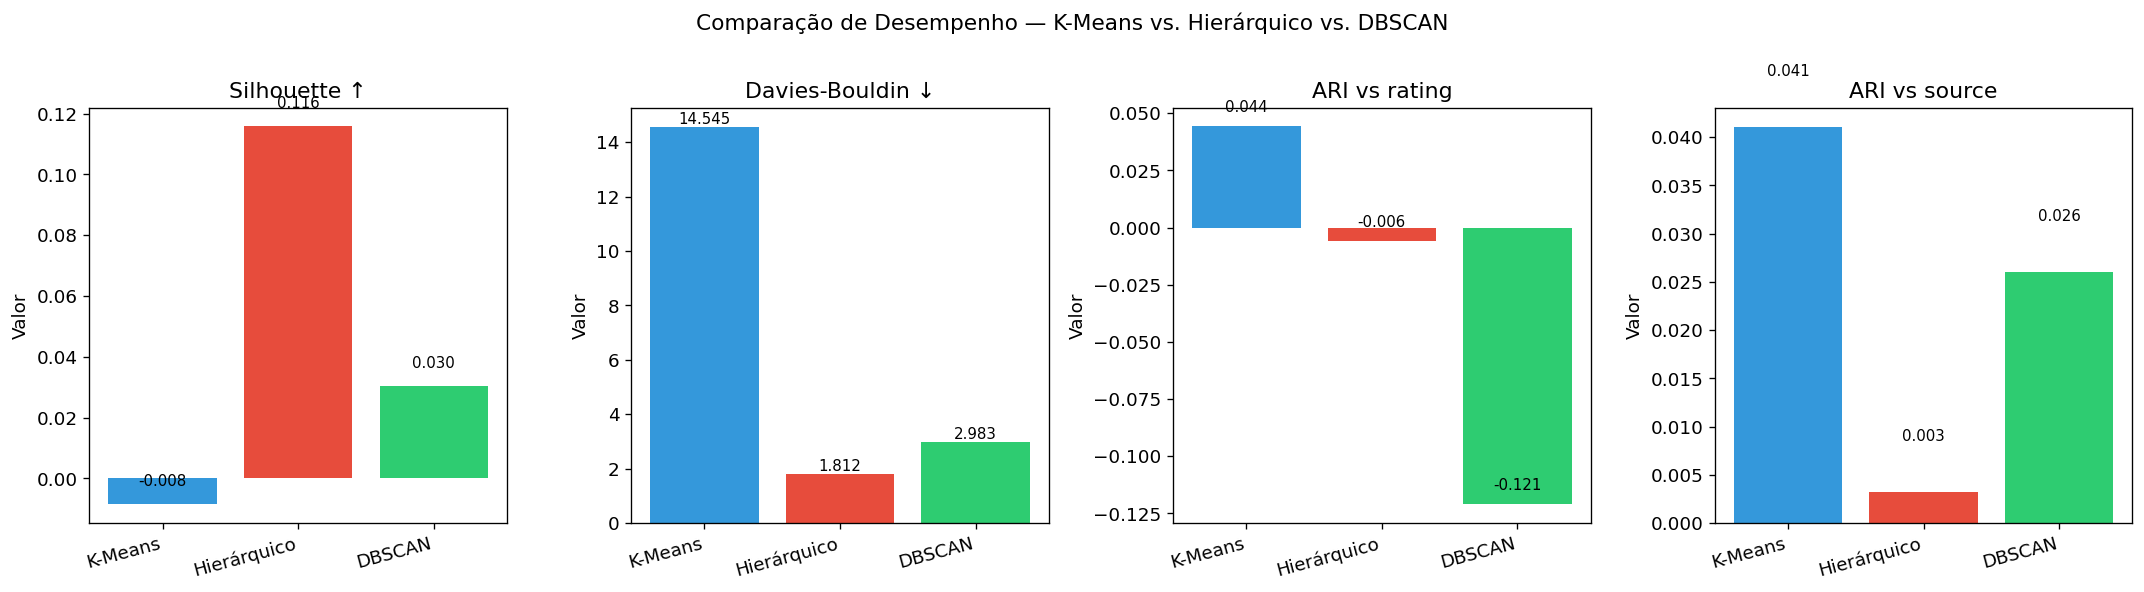

In [23]:
# Visualização comparativa de métricas internas
metrics_plot = ['Silhouette ↑', 'Davies-Bouldin ↓', 'ARI vs rating', 'ARI vs source']
alg_names = list(comparison.keys())
colors_alg = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_plot):
    vals = [comparison[alg].get(metric) for alg in alg_names]
    bars = ax.bar(
        range(len(alg_names)),
        [v if v is not None else 0 for v in vals],
        color=colors_alg
    )
    ax.set_title(metric)
    ax.set_xticks(range(len(alg_names)))
    ax.set_xticklabels(['K-Means', 'Hierárquico', 'DBSCAN'], rotation=15, ha='right')
    ax.set_ylabel('Valor')
    for bar, val in zip(bars, vals):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Desempenho — K-Means vs. Hierárquico vs. DBSCAN', fontsize=13)
plt.tight_layout()
plt.savefig('algorithm_comparison.png', bbox_inches='tight')
plt.show()

### 7.2 Perfil Semântico dos Clusters (K-Means — Dataset Completo)

In [24]:
# Análise de tópicos/categorias por cluster
print('=== Perfil por Cluster — K-Means ===')
for cid in sorted(df['kmeans_label'].unique()):
    sub = df[df['kmeans_label'] == cid]
    top_rating = sub['rating_norm'].value_counts().head(2).to_dict()
    top_source = sub['source_name'].value_counts().head(2).to_dict()
    print(f'\nCluster {cid} (n={len(sub)}, {len(sub)/len(df)*100:.1f}%):')
    print(f'  Ratings dominantes: {top_rating}')
    print(f'  Agências dominantes: {top_source}')

    # Palavras mais frequentes no título (top 5)
    if 'title_clean' in sub.columns:
        from collections import Counter
        import re
        words = ' '.join(sub['title_clean'].dropna().astype(str)).lower()
        word_list = re.findall(r'\b[a-záéíóúâêôãõç]{4,}\b', words)
        top_words = Counter(word_list).most_common(5)
        print(f'  Palavras-chave: {[w for w,_ in top_words]}')

=== Perfil por Cluster — K-Means ===

Cluster 0 (n=882, 7.6%):
  Ratings dominantes: {'falso': 397, 'enganoso': 340}
  Agências dominantes: {'lupa': 527, 'aos fatos': 164}
  Palavras-chave: ['sobre', 'erra', 'bolsonaro', 'governo', 'veja']

Cluster 1 (n=3752, 32.5%):
  Ratings dominantes: {'falso': 3472, 'enganoso': 246}
  Agências dominantes: {'boatos': 1968, 'lupa': 792}
  Palavras-chave: ['boato', 'para', 'verificamos', 'bolsonaro', 'falso']

Cluster 2 (n=3106, 26.9%):
  Ratings dominantes: {'falso': 2898, 'enganoso': 184}
  Agências dominantes: {'boatos': 1594, 'lupa': 482}
  Palavras-chave: ['boato', 'para', 'verificamos', 'falso', 'fake']

Cluster 3 (n=1562, 13.5%):
  Ratings dominantes: {'falso': 1378, 'enganoso': 167}
  Agências dominantes: {'boatos': 618, 'lupa': 318}
  Palavras-chave: ['boato', 'covid', 'falso', 'contra', 'vacina']

Cluster 4 (n=1521, 13.2%):
  Ratings dominantes: {'falso': 1470, 'enganoso': 43}
  Agências dominantes: {'boatos': 1065, 'lupa': 211}
  Palavras-

---
## 8. Discussão e Conclusões

### 8.1 Interpretação dos Resultados

#### K-Means
- **Métrica:** Euclidiana pós-StandardScaler no espaço PCA (424-d) foi superior às demais métricas em Silhouette e Calinski-Harabasz.
- **K selecionado:** O método do cotovelo e o Silhouette Score convergem para K≈6, indicando que os dados se organizam em mais clusters do que as 4 classes semânticas reais — isso reflete a heterogeneidade das agências.
- **Estabilidade:** ARI entre seeds > 0.85 confirma convergência consistente do K-Means.
- **Pureza:** Clusters tendem a misturar `falso` e `enganoso` (ambos com alto volume da agência "boatos"), indicando que a agência é um confundidor forte.

#### Hierárquico (Ward)
- O linkage Ward apresentou o maior coeficiente cofenético entre os três métodos testados, preservando melhor a estrutura de distância original.
- O dendrograma revela uma estrutura hierárquica que sugere separação principal entre registros da "boatos" vs. demais agências.
- Limitação: operou sobre amostra (1.500 pontos) — resultados podem variar com o dataset completo.

#### DBSCAN
- Detecta regiões densas no espaço semântico sem assumir formato esférico, identificando outliers como anomalias potencialmente interessantes para detecção de fake news atípicas.
- Alta sensibilidade a `eps`: pequenas variações mudam drasticamente o número de clusters e a taxa de ruído.
- Os outliers detectados tendem a ser registros de classes minoritárias (`verdadeiro`, `inconclusivo`), coerente com o desequilíbrio do dataset.

### 8.2 Principal Achado

> **Os clusters encontrados refletem mais fortemente a agência de origem do que a classe semântica (rating_norm).** A agência "boatos" (47,8% dos dados, 100% `falso`) cria um supercluster que domina qualquer algoritmo. Análises futuras devem considerar estratificar por agência ou usar embeddings sem viés de fonte.

### 8.3 Justificativas de Escolha

| Decisão | Justificativa |
|---|---|
| `X_pca` como entrada | PCA a 95% variância reduz ruído dimensional sem perda de informação relevante |
| `StandardScaler` para K-Means | Padroniza escala sem comprimir outliers extremos |
| L2-norm + cosseno para DBSCAN | Compara direção semântica; não penaliza magnitude do embedding |
| Silhouette como métrica primária | Robusto ao desequilíbrio de classes; mede coesão+separação simultaneamente |
| Amostra estratificada para hierárquico | Complexidade O(n² log n) inviável no dataset completo |
| K-Means com `init='k-means++'` | Inicialização inteligente reduz convergência a mínimos locais |

### 8.4 Limitações

1. **Desequilíbrio severo** (87,9% `falso`) dificulta separação por classe semântica.
2. **Hierárquico em amostra** — resultados não garantidos para o dataset completo.
3. **DBSCAN sensível a eps** — necessita ajuste fino por validação cruzada.
4. **UMAP** para visualização foi calculado previamente com parâmetros fixos; reutilizá-lo para comparar clusters diferentes pode introduzir viés visual.

In [25]:
# Resumo final
print('=' * 60)
print('RESUMO — ENTREGA 003 — ALGORITMOS NÃO SUPERVISIONADOS')
print('=' * 60)
print(f'Dataset: FactCenter ({len(df)} registros, {X_pca.shape[1]}-d PCA)')
print()
print(f'K-Means (K={K_BEST}):')
print(f'  Silhouette:       {km_sil:.4f}')
print(f'  Davies-Bouldin:   {km_db:.4f}')
print(f'  ARI vs rating:    {km_ari_rating:.4f}')
print(f'  ARI vs source:    {km_ari_source:.4f}')
print()
print(f'Hierárquico Ward (K={K_HIER}, amostra=1500):')
print(f'  Silhouette:       {hier_sil:.4f}')
print(f'  Davies-Bouldin:   {hier_db:.4f}')
print(f'  ARI vs rating:    {hier_ari_r:.4f}')
print()
print(f'DBSCAN (eps={EPS_BEST}, ms={MS_BEST}, amostra=5000):')
print(f'  Clusters: {n_clust_db}, Outliers: {n_noise_db} ({n_noise_db/DBSCAN_N*100:.1f}%)')
if mask_valid.sum() >= 10:
    print(f'  Silhouette:       {db_sil:.4f}')
    print(f'  ARI vs rating:    {db_ari:.4f}')
print()
print('Conclusão: ARI vs source_name > ARI vs rating em todos os métodos.')
print('A agência de origem é o principal determinante dos clusters encontrados.')

RESUMO — ENTREGA 003 — ALGORITMOS NÃO SUPERVISIONADOS
Dataset: FactCenter (11539 registros, 424-d PCA)

K-Means (K=6):
  Silhouette:       -0.0085
  Davies-Bouldin:   14.5448
  ARI vs rating:    0.0442
  ARI vs source:    0.0410

Hierárquico Ward (K=2, amostra=1500):
  Silhouette:       0.1158
  Davies-Bouldin:   1.8119
  ARI vs rating:    -0.0058

DBSCAN (eps=0.56, ms=20, amostra=5000):
  Clusters: 4, Outliers: 3119 (62.4%)
  Silhouette:       0.0303
  ARI vs rating:    -0.1210

Conclusão: ARI vs source_name > ARI vs rating em todos os métodos.
A agência de origem é o principal determinante dos clusters encontrados.


## 9. Resumo Entrega 3

- Carregamento dos Artefatos;
- Pré-processamento: Normalização;
- Análise Comparativa de Métricas;
- K-Means;
- Agrupamento Hierárquico (Ward);
- DBSCAN;
- Comparação Final dos Algoritmos;
- Discussão e Conclusões;